In [34]:
from mermaid import Mermaid
print("coloring problem graph:\n")
graph = Mermaid("""
graph LR
    A1((A1))
    A2((A2))
    A3((A3))
    A4((A4))
    H((H))
    T((T))
    F1((F1))
    F2((F2))
    
    A1 --- A2
    A2 --- A3
    A3 --- A4
    
    A1 --- H
    A2 --- H
    A3 --- H
    A4 --- H
    
    H --- T
    
    T --- F1
    T --- F2
                
    style A1 fill:red, color:white
    style H fill:green, color:white
    style A4 fill:blue, color:white
    style F1 fill:red, color:white
    style A2 fill:blue, color:white
    style F2 fill:red, color:white
    style A3 fill:red, color:white
    style T fill:blue, color:white
    
                
""")
graph

coloring problem graph:



Find a 3-coloring of this graph by hand.

X: {A1, A2, A3, A4, H, T, F1, F2}
D: {RGB}
C: { X_i != X_j}

strategy:
- backtracking
  - conflict-directed backjumping
  - the variable order A1, H, A4, F1, A2, F2, A3, T
  - value order R, G, B.

A1 = R
H = (R) -> H = G
  Conf(H: A1)
A4 = R
F1 = R
A2 = (R) -> (G) -> B
  Conf(A2: A1 H)
F2 = R
A3 = (R) -> (G) -> (B)
  Conf(A3: A4 H A2) failure: -> A2 try new color
  Conf(A2: A1 H A4) failure: -> A4 try new color
  Conf(A4: A1 H) success: -> continue
  Conf(H: A1)

A2 = (A1=R) (H=G) = subset(Conf(A1 H A4))
A4 = subset(conf(H=G)) -> B
A3 = subset(Conf(H=G A2=B)) -> R
T = (F1:R) -> (H:G) -> B
  Conf(T: F1 H)

solution: A1=R, A2=B, A3=R, A4=B, H=G, T=B, F1=R, F2=R


### Rectilinear floor-planning

We fix the container to a width of 15 and a height of 10 to keep the example concrete. Each small rectangle `R1`..`Rn` becomes a CSP variable whose value is a placement tuple `(x, y)` inside `{0..W-w_i} \times {0..H-h_i}`. Pairwise binary constraints enforce the textbook disjunctive separation: for each pair the placement has to be left-of, right-of, below, or above the other.

This section sticks to a single search order: MRV-driven backtracking with MAC (AC3b) inference and the default domain ordering. The heuristics choices are documented probabilistically:

1. **Variable ordering (`mrv`)** 
- Claim: MRV focuses the search on rectangles whose legal placements rapidly shrink, shrinking the branching factor early. 
- Rebate: MRV recalculates `num_legal_values` at every node, but because the domains are bounded by the container dimension and there are only a few neighbors, the extra scanning is lightweight compared to the savings.

2. **Inference (`mac`)** 
- Claim: Maintaining arc consistency after each assignment eliminates placements that would trigger a disjunction failure and keeps the search tree shallow.
- Rebate: The propagation cost could dominate if domains were huge, yet here each domain is bounded by a few dozen coordinate pairs, so AC3b stays fast.

The following code uses the existing `CSP` scaffolding (a generalization of `different_values_constraint`) to deliver a correct, simple, and explainable solution.

In [83]:
import sys
import time
from itertools import combinations
from pathlib import Path

repo_root = Path.cwd()
while not (repo_root / "csp.py").exists():
    parent = repo_root.parent
    if parent == repo_root:
        raise RuntimeError("Cannot locate the repo root containing csp.py")
    repo_root = parent

sys.path.append(str(repo_root))

from csp import CSP, backtracking_search, mrv, mac, unordered_domain_values

W, H = 15, 10
rectangles = {
    "R1": (4, 3),
    "R2": (3, 2),
    "R3": (5, 2),
    "R4": (2, 4),
}

def placements_for(name):
    w, h = rectangles[name]
    return [(x, y) for x in range(W - w + 1) for y in range(H - h + 1)]


# the non-overlapping constraint
def non_overlap(A, a, B, b):  
    if A == B:
        return True
    x_a, y_a = a
    x_b, y_b = b
    w_a, h_a = rectangles[A]
    w_b, h_b = rectangles[B]

    # Axis-aligned disjunctive ensures rectangles do not intersect.
    return (
        x_a + w_a <= x_b
        or x_b + w_b <= x_a
        or y_a + h_a <= y_b
        or y_b + h_b <= y_a
    )


def gather_metrics(csp, domains, elapsed, entity_label="entities", entity_count=None, legacy_key=None):
    count = entity_count if entity_count is not None else len(domains)
    result = {
        "elapsed_seconds": round(elapsed, 4),
        "assignments": csp.nassigns,
        "total_domain_options": sum(len(values) for values in domains.values()),
    }
    result[entity_label] = count
    if legacy_key and legacy_key not in result:
        result[legacy_key] = count
    return result


def check_non_overlapping(assignment):
    for r1, r2 in combinations(rectangles, 2):
        if not non_overlap(r1, assignment[r1], r2, assignment[r2]):
            return False
    return True


domains = {name: placements_for(name) for name in rectangles}
neighbors = {name: [other for other in rectangles if other != name] for name in rectangles}

floor_csp = CSP(list(rectangles), domains, neighbors, non_overlap)
start_time = time.perf_counter()
solution = backtracking_search(
    floor_csp,
    select_unassigned_variable=mrv,
    order_domain_values=unordered_domain_values,
    inference=mac,
)
elapsed_time = time.perf_counter() - start_time
metrics = gather_metrics(floor_csp, domains, elapsed_time, entity_label="rectangles")


In [84]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle


def draw_rectangular_layout(
    assignments,
    dims,
    metrics,
    title,
    entity_label,
    label_fn=None,
    palette=None,
    axis=None,
    figure_size=(6, 5),
):
    created_fig = axis is None
    if created_fig:
        fig, axis = plt.subplots(figsize=figure_size)
    else:
        fig = axis.figure
    axis.set_xlim(0, dims[0])
    axis.set_ylim(0, dims[1])
    axis.set_aspect("equal")
    axis.add_patch(Rectangle((0, 0), dims[0], dims[1], fill=False, linewidth=1.5, edgecolor="black"))

    palette = palette or ["tab:blue", "tab:orange", "tab:green", "tab:red", "tab:purple"]
    for idx, (name, rect) in enumerate(assignments.items()):
        x, y, w, h = rect
        color = palette[idx % len(palette)]
        axis.add_patch(Rectangle((x, y), w, h, facecolor=color, alpha=0.5, edgecolor="black"))
        label = label_fn(name) if label_fn else name
        axis.text(x + w / 2, y + h / 2, label, ha="center", va="center", weight="bold", color="black")

    entity_value = metrics.get(entity_label) or metrics.get("entities")
    entity_line = f"{entity_label.title()}: {entity_value}\n" if entity_value is not None else ""
    metrics_text = (
        f"Time: {metrics['elapsed_seconds']}s\n"
        f"Assigns: {metrics['assignments']}\n"
        f"{entity_line}"
        f"Domains: {metrics['total_domain_options']}"
    )
    axis.text(
        0.95,
        0.95,
        metrics_text,
        ha="right",
        va="top",
        transform=axis.transAxes,
        bbox=dict(facecolor="white", alpha=0.75, edgecolor="gray"),
        fontsize="small",
    )

    axis.set_title(title)
    axis.set_xlabel("x")
    axis.set_ylabel("y")
    axis.set_xticks(range(int(dims[0]) + 1))
    axis.set_yticks(range(int(dims[1]) + 1))
    axis.grid(True, linestyle="--", linewidth=0.5, color="gray")

    if created_fig:
        plt.tight_layout()
        plt.show()
    return fig, axis


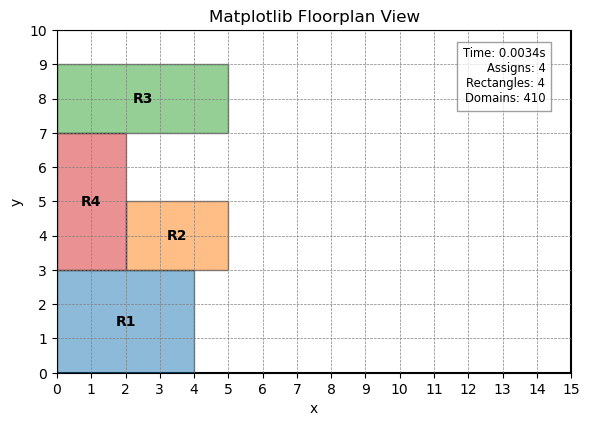

(<Figure size 600x500 with 1 Axes>,
 <Axes: title={'center': 'Matplotlib Floorplan View'}, xlabel='x', ylabel='y'>)

In [89]:
# display floorplan

floor_assignments = {
    name: (
        solution[name][0],
        solution[name][1],
        rectangles[name][0],
        rectangles[name][1],
    )
    for name in sorted(solution)
}

draw_rectangular_layout(
    floor_assignments,
    (W, H),
    metrics,
    "Matplotlib Floorplan View",
    entity_label="rectangles",
)


### Class scheduling CSP

We fix a tiny department with three time slots, a handful of rooms, and professors who can teach certain courses. Each course is assigned a `(time, room, professor)` tuple, and the constraint function enforces the usual pairing of time/room exclusivity, professor availability, and explicit student-group conflicts. This keeps the modular `Time/Room/Prof` triplet view while the helper below is ready for extra rules (capacity, equipment, etc.) down the road.

The next code cell creates the CSP, runs both backtracking and graph search variants, and renders the schedule with the same reusable layout helper so the visualization story stays consistent.

Backtracking solution:
CS101: t2, Room A, Prof Kim
MATH1: t1, Room A, Prof Lee
PHYS2: t1, Room B, Prof Kim
Metrics: {'elapsed_seconds': 0.0007, 'assignments': 3, 'total_domain_options': 33, 'classes': 3}
Graph search also found solution:
  CS101: t3, Room B, Prof Lee
  MATH1: t3, Room C, Prof Xu
  PHYS2: t2, Room B, Prof Kim
Graph metrics: {'elapsed_seconds': 0.0014, 'assignments': 0, 'total_domain_options': 33, 'classes': 3}


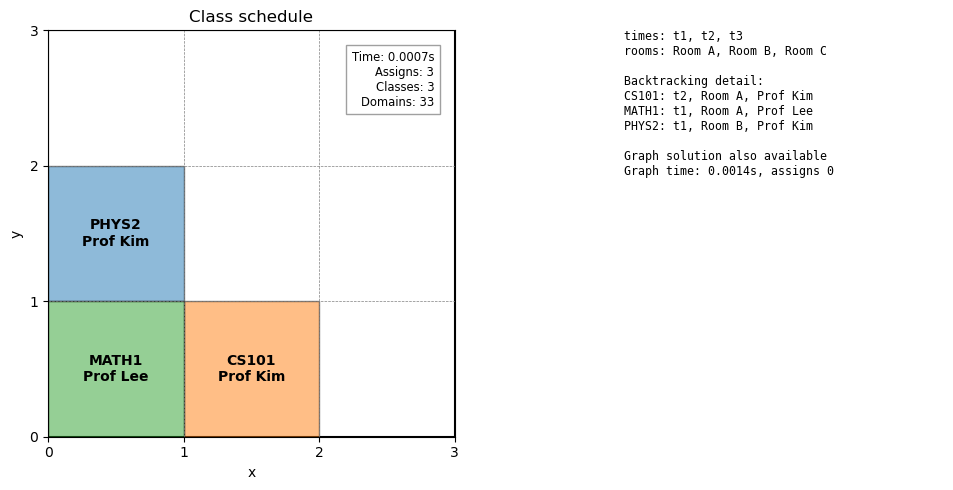

In [88]:
import search
from copy import deepcopy
from itertools import product

# Problem data
classes = ["CS101", "MATH1", "PHYS2"]
time_slots = ["t1", "t2", "t3"]
rooms = {
    "Room A": {"capacity": 30, "equipment": {"projector"}},
    "Room B": {"capacity": 25, "equipment": {"projector", "lab"}},
    "Room C": {"capacity": 20, "equipment": set()},
}
professors = ["Prof Kim", "Prof Lee", "Prof Xu"]
eligible_professors = {
    "CS101": ["Prof Kim", "Prof Lee"],
    "MATH1": ["Prof Lee", "Prof Xu"],
    "PHYS2": ["Prof Kim"],
}
class_sizes = {"CS101": 25, "MATH1": 20, "PHYS2": 15}
class_requirements = {"CS101": {"projector"}, "MATH1": set(), "PHYS2": {"lab"}}
shared_student_conflicts = {frozenset({"CS101", "PHYS2"})}

def room_can_host(cls_name, room_name):
    room = rooms[room_name]
    if room["capacity"] < class_sizes[cls_name]:
        return False
    if not class_requirements[cls_name].issubset(room["equipment"]):
        return False
    return True


def future_rules(cls_name, time_slot, room_name, professor):
    # Placeholder for licensing, preferred times, etc.
    return True

def build_domains():
    domains = {}
    room_choices = {
        cls: [room for room in rooms if room_can_host(cls, room)]
        for cls in classes
    }
    for cls in classes:
        domain = [
            (time_slot, room, prof)
            for time_slot, room, prof in product(time_slots, room_choices[cls], eligible_professors[cls])
            if future_rules(cls, time_slot, room, prof)
        ]
        domains[cls] = domain
    return domains


def schedule_constraint(A, a, B, b):
    if A == B:
        return True
    time_a, room_a, prof_a = a
    time_b, room_b, prof_b = b
    if time_a == time_b:
        if room_a == room_b or prof_a == prof_b:
            return False
        if frozenset({A, B}) in shared_student_conflicts:
            return False
    return True


domains_base = build_domains()
neighbors = {cls: [other for other in classes if other != cls] for cls in classes}

schedule_csp_bt = CSP(classes, deepcopy(domains_base), neighbors, schedule_constraint)
start_time_bt = time.perf_counter()
schedule_solution = backtracking_search(
    schedule_csp_bt,
    select_unassigned_variable=mrv,
    order_domain_values=unordered_domain_values,
    inference=mac,
)
elapsed_bt = time.perf_counter() - start_time_bt
metrics_bt = gather_metrics(schedule_csp_bt, schedule_csp_bt.domains, elapsed_bt, entity_label="classes")

print("Backtracking solution:")
if schedule_solution:
    for cls in sorted(schedule_solution):
        time_slot, room, prof = schedule_solution[cls]
        print(f"{cls}: {time_slot}, {room}, {prof}")
else:
    print("  None found")
print("Metrics:", metrics_bt)

schedule_csp_graph = CSP(classes, deepcopy(domains_base), neighbors, schedule_constraint)
start_time_graph = time.perf_counter()
graph_node = search.depth_first_graph_search(schedule_csp_graph)
elapsed_graph = time.perf_counter() - start_time_graph
metrics_graph = gather_metrics(schedule_csp_graph, schedule_csp_graph.domains, elapsed_graph, entity_label="classes")

if graph_node:
    graph_solution = dict(graph_node.state)
    print("Graph search also found solution:")
    for cls in sorted(graph_solution):
        time_slot, room, prof = graph_solution[cls]
        print(f"  {cls}: {time_slot}, {room}, {prof}")
else:
    graph_solution = None
    print("Graph search did not finish with a complete assignment.")
print("Graph metrics:", metrics_graph)

# Visualization of the backtracking result
if schedule_solution:
    time_index = {time: idx for idx, time in enumerate(time_slots)}
    room_index = {room: idx for idx, room in enumerate(rooms)}
    schedule_assignments = {
        cls: (time_index[vals[0]], room_index[vals[1]], 1, 1)
        for cls, vals in schedule_solution.items()
    }
    fig, (ax_schedule, ax_notes) = plt.subplots(1, 2, figsize=(12, 5), gridspec_kw={"width_ratios": [3, 1]})
    draw_rectangular_layout(
        schedule_assignments,
        (len(time_slots), len(rooms)),
        metrics_bt,
        "Class schedule",
        entity_label="classes",
        label_fn=lambda name: f"{name}\n{schedule_solution[name][2]}", # type: ignore
        axis=ax_schedule,
    )
    ax_notes.axis("off")
    note_lines = [f"times: {', '.join(time_slots)}", f"rooms: {', '.join(rooms)}"]
    note_lines.append("\nBacktracking detail:")
    note_lines.extend(
        [f"{cls}: {schedule_solution[cls][0]}, {schedule_solution[cls][1]}, {schedule_solution[cls][2]}" for cls in sorted(schedule_solution)]
    )
    if graph_solution:
        note_lines.append("\nGraph solution also available")
    else:
        note_lines.append("\nGraph search incomplete")
    note_lines.append(f"Graph time: {metrics_graph['elapsed_seconds']}s, assigns {metrics_graph['assignments']}")
    ax_notes.text(0, 1, "\n".join(note_lines), va="top", fontsize="small", family="monospace")
    plt.tight_layout()
    plt.show()
else:
    print("Skipping visualization because no solution was computed.")


Successor-based Hamiltonian cycle (CSP): A -> B -> C -> E -> D -> F -> A
Successors / order:
  A -> B (order 0)
  B -> C (order 1)
  C -> E (order 2)
  E -> D (order 3)
  D -> F (order 4)
  F -> A (order 5)
CSP metrics: {'elapsed_seconds': 0.1761, 'assignments': 14636, 'total_domain_options': 56, 'nodes': 12}
Depth-first graph search cycle: A -> F -> E -> D -> C -> B -> A
Graph metrics: {'elapsed_seconds': 0.0001, 'cycle_length': 6, 'assignments': 0, 'total_domain_options': 0}


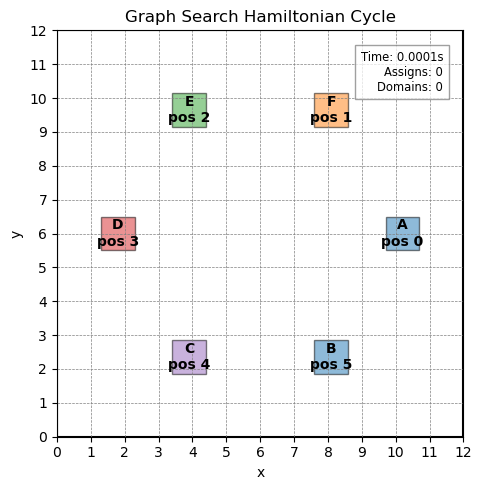

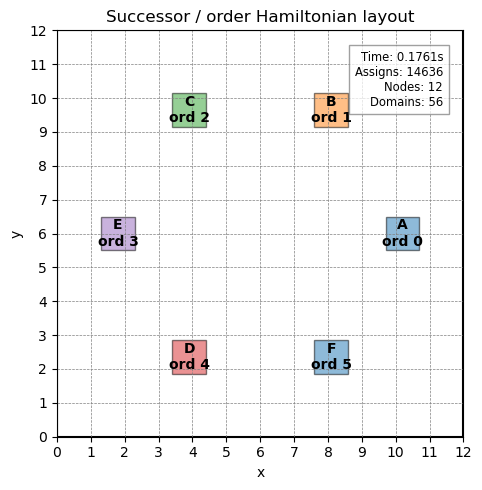

In [94]:
import math
import time
import search

from csp import Constraint, NaryCSP, all_diff_constraint

nodes = ["A", "B", "C", "D", "E", "F"]
graph = {
    "A": ["B", "C", "F"],
    "B": ["A", "C", "D"],
    "C": ["A", "B", "D", "E"],
    "D": ["B", "C", "E", "F"],
    "E": ["C", "D", "F"],
    "F": ["A", "D", "E"],
}

total_nodes = len(nodes)
successor_vars = {node: f"next_{node}" for node in nodes}
order_vars = {node: f"order_{node}" for node in nodes}

domains = {
    successor_vars[node]: list(graph[node])
    for node in nodes
}

domains.update({order_vars[node]: list(range(total_nodes)) for node in nodes}) # type: ignore

def successor_order_constraint(successor):
    def constraint(next_val, order_val, successor_order):
        if next_val != successor:
            return True
        expected = (order_val + 1) % total_nodes
        return successor_order == expected

    return constraint

constraints = [
    Constraint(tuple(order_vars.values()), all_diff_constraint),
]

for node in nodes:
    next_var = successor_vars[node]
    order_var = order_vars[node]
    for neighbor in graph[node]:
        constraints.append(
            Constraint(
                (next_var, order_var, order_vars[neighbor]),
                successor_order_constraint(neighbor),
            )
        )

hamiltonian_csp = NaryCSP({var: list(values) for var, values in domains.items()}, constraints)


def solve_nary_backtracking(csp):
    variables = list(csp.domains)
    assignment = {}
    csp.nassigns = 0

    def select_unassigned():
        unassigned = [v for v in variables if v not in assignment]
        return min(unassigned, key=lambda v: len(csp.domains[v]))

    def backtrack():
        if len(assignment) == len(variables):
            return dict(assignment)
        var = select_unassigned()
        for value in csp.domains[var]:
            assignment[var] = value
            csp.nassigns += 1
            if csp.consistent(assignment):
                result = backtrack()
                if result:
                    return result
            assignment.pop(var)
        return None

    return backtrack()

start_time_bt = time.perf_counter()
hamiltonian_solution = solve_nary_backtracking(hamiltonian_csp)
elapsed_bt = time.perf_counter() - start_time_bt
metrics_bt = gather_metrics(hamiltonian_csp, hamiltonian_csp.domains, elapsed_bt, entity_label="nodes")

if hamiltonian_solution:
    successor_map = {node: hamiltonian_solution[successor_vars[node]] for node in nodes}
    order_map = {node: hamiltonian_solution[order_vars[node]] for node in nodes}
    ordered_nodes = sorted(nodes, key=lambda node: order_map[node])
    cycle_display = " -> ".join(ordered_nodes + [ordered_nodes[0]])
    print("Successor-based Hamiltonian cycle (CSP):", cycle_display)
    print("Successors / order:")
    for node in ordered_nodes:
        print(f"  {node:>1} -> {successor_map[node]} (order {order_map[node]})")
else:
    print("No CSP solution emerged.")

print("CSP metrics:", metrics_bt)

class HamiltonianCycleProblem(search.Problem):
    def __init__(self, graph, start):
        super().__init__((start,))
        self.graph = graph
        self.start = start
        self.nodes = list(graph)

    def actions(self, state):
        last = state[-1]
        if len(state) == len(self.nodes):
            return [self.start] if self.start in self.graph[last] else []
        return [nbr for nbr in self.graph[last] if nbr not in state]

    def result(self, state, action):
        return state + (action,)

    def goal_test(self, state):
        return len(state) == len(self.nodes) + 1 and state[-1] == self.start

graph_problem = HamiltonianCycleProblem(graph, nodes[0])
start_time_graph = time.perf_counter()
graph_node = search.depth_first_graph_search(graph_problem)
elapsed_graph = time.perf_counter() - start_time_graph

graph_cycle = ()
if graph_node:
    graph_cycle = graph_node.state[:-1]
    graph_cycle_display = " -> ".join(graph_cycle + (graph_cycle[0],))
    print("Depth-first graph search cycle:", graph_cycle_display)
else:
    graph_cycle_display = None
    print("Graph search failed to close a Hamiltonian tour.")

graph_metrics = {
    "elapsed_seconds": round(elapsed_graph, 4),
    "cycle_length": len(graph_cycle),
    "assignments": 0,  # Graph search doesn't track assignments like CSP
    "total_domain_options": 0,  # Not applicable to graph search
}
print("Graph metrics:", graph_metrics)

# Visualize graph search solution if found
if graph_cycle:
    dims = (12, 12)
    center = (dims[0] / 2, dims[1] / 2)
    radius = min(dims) * 0.35
    graph_layout = {}
    for idx, node in enumerate(graph_cycle):
        angle = 2 * math.pi * idx / len(graph_cycle)
        x = center[0] + radius * math.cos(angle) - 0.5
        y = center[1] + radius * math.sin(angle) - 0.5
        graph_layout[node] = (x, y, 1, 1)

    fig, axis = draw_rectangular_layout(
        graph_layout,
        dims,
        graph_metrics,
        "Graph Search Hamiltonian Cycle",
        entity_label="nodes",
        label_fn=lambda name: f"{name}\npos {graph_cycle.index(name)}",
    )

    # Draw cycle edges
    for i in range(len(graph_cycle)):
        current = graph_cycle[i]
        next_node = graph_cycle[(i + 1) % len(graph_cycle)]
        start_rect = graph_layout[current]
        end_rect = graph_layout[next_node]
        axis.annotate(
            "",
            xy=(end_rect[0] + 0.5, end_rect[1] + 0.5),
            xytext=(start_rect[0] + 0.5, start_rect[1] + 0.5),
            arrowprops=dict(arrowstyle="->", color="blue"),
        )


if hamiltonian_solution:
    dims = (12, 12)
    center = (dims[0] / 2, dims[1] / 2)
    radius = min(dims) * 0.35
    layout = {}
    for node in nodes:
        angle = 2 * math.pi * order_map[node] / total_nodes
        x = center[0] + radius * math.cos(angle) - 0.5
        y = center[1] + radius * math.sin(angle) - 0.5
        layout[node] = (x, y, 1, 1)

    fig, axis = draw_rectangular_layout(
        layout,
        dims,
        metrics_bt,
        "Successor / order Hamiltonian layout",
        entity_label="nodes",
        label_fn=lambda name: f"{name}\nord {order_map[name]}",
    )

    for node, successor in successor_map.items():
        start_rect = layout[node]
        end_rect = layout[successor]
        axis.annotate(
            "",
            xy=(end_rect[0] + 0.5, end_rect[1] + 0.5),
            xytext=(start_rect[0] + 0.5, start_rect[1] + 0.5),
            arrowprops=dict(arrowstyle="->", color="black"),
        )